In [16]:
import cv2                
import numpy as np         
import os                  
from random import shuffle
from tqdm import tqdm

In [17]:
TRAIN_DIR = 'data\\train\\'
TEST_DIR = 'data\\test\\'
IMG_SIZE = 224
LR = 1e-3

In [18]:
def label_img(folder_name):
    if folder_name == 'cats': return [1,0]
    elif folder_name == 'dogs': return [0,1]

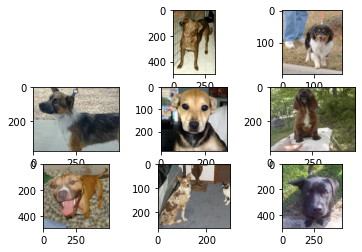

In [19]:
from matplotlib import pyplot
from matplotlib.image import imread
folder = 'data\\train\\dogs\\'
for i in range(1,9):
    pyplot.subplot(330 + 1 + i)
    filename = folder + str(i) + '.jpg'
    image = imread(filename)
    pyplot.imshow(image)
pyplot.show()

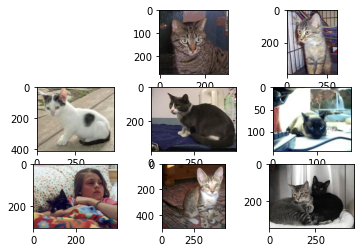

In [20]:
folder = 'data\\train\\cats\\'
for i in range(1,9):
    pyplot.subplot(330 + 1 + i)
    filename = folder + str(i) + '.jpg'
    image = imread(filename)
    pyplot.imshow(image)
pyplot.show()

In [21]:
def create_train_data():
    training_data = []
    for n,folder in enumerate(os.listdir(TRAIN_DIR)):
      images = os.listdir(os.path.join(TRAIN_DIR,folder))
      for i,image in enumerate(images):
        label = label_img(folder)
        path = os.path.join(TRAIN_DIR,folder,image)
        img = cv2.imread(path,cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (IMG_SIZE,IMG_SIZE))
        training_data.append([np.array(img),np.array(label)])
    shuffle(training_data)
    np.save('train_data.npy', training_data)
    return training_data

In [22]:
X = create_train_data()

C:\ProgramData\Anaconda3\lib\site-packages\numpy\core\_asarray.py:171: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order, subok=True)


In [23]:
os.getcwd()

'C:\\Users\\rahul'

In [24]:
def create_test_data():
    test_data = []
    for n,folder in enumerate(os.listdir(TEST_DIR)):
      images = os.listdir(os.path.join(TEST_DIR,folder))
      for i,image in enumerate(images):
        label = label_img(folder)
        path = os.path.join(TEST_DIR,folder,image)
        img = cv2.imread(path,cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (IMG_SIZE,IMG_SIZE))
        img = img/255
        test_data.append([np.array(img),np.array(label)])
    shuffle(test_data)
    np.save('test_data.npy', test_data)
    return test_data

In [25]:
Y = create_test_data()

In [26]:
import tflearn
from tflearn.layers.conv import conv_2d, max_pool_2d
from tflearn.layers.core import input_data, dropout, fully_connected
from tflearn.layers.estimator import regression

convnet = input_data(shape=[None, IMG_SIZE, IMG_SIZE, 1], name='input')

convnet = conv_2d(convnet, 32, 5, activation='relu')
convnet = max_pool_2d(convnet, 2,strides = 2)

convnet = conv_2d(convnet, 64, 5, activation='relu')
convnet = max_pool_2d(convnet, 2,strides = 2)
convnet = fully_connected(convnet, 32, activation='relu')
convnet = dropout(convnet, 0.6)

convnet = fully_connected(convnet, 2, activation='softmax')
convnet = regression(convnet, optimizer='adam', learning_rate=LR, loss='categorical_crossentropy', name='targets')

model = tflearn.DNN(convnet, tensorboard_dir='log')

In [27]:
train = X
test = Y

In [28]:
X = np.array([i[0] for i in train]).reshape(-1,IMG_SIZE,IMG_SIZE,1)
Y = [i[1] for i in train]

test_x = np.array([i[0] for i in test]).reshape(-1,IMG_SIZE,IMG_SIZE,1)
test_y = [i[1] for i in test]

In [13]:
MODEL_NAME = 'pet_classifier_2_Conv_basic'
model.fit({'input': X}, {'targets': Y}, n_epoch=300, validation_set=({'input': test_x}, {'targets': test_y}), 
    snapshot_step=500, show_metric=True, run_id=MODEL_NAME)

---------------------------------
Run id: pet_classifier_2_Conv_basic
Log directory: log/
INFO:tensorflow:Summary name Accuracy/ (raw) is illegal; using Accuracy/__raw_ instead.
---------------------------------
Training samples: 40
Validation samples: 20
--
Training Step: 1  | time: 2.301s
| Adam | epoch: 001 | loss: 0.00000 - acc: 0.0000 | val_loss: 1.13042 - val_acc: 0.5000 -- iter: 40/40
--
Training Step: 2  | total loss: 7.44949 | time: 1.929s
| Adam | epoch: 002 | loss: 7.44949 - acc: 0.4500 | val_loss: 2.01590 - val_acc: 0.5000 -- iter: 40/40
--
Training Step: 3  | total loss: 10.30314 | time: 1.938s
| Adam | epoch: 003 | loss: 10.30314 - acc: 0.5114 | val_loss: 3.00001 - val_acc: 0.5000 -- iter: 40/40
--
Training Step: 4  | total loss: 10.77874 | time: 2.102s
| Adam | epoch: 004 | loss: 10.77874 - acc: 0.5216 | val_loss: 4.00262 - val_acc: 0.5000 -- iter: 40/40
--
Training Step: 5  | total loss: 11.28702 | time: 2.097s
| Adam | epoch: 005 | loss: 11.28702 - acc: 0.5066 | val_lo

Training Step: 45  | total loss: 11.49966 | time: 1.938s
| Adam | epoch: 045 | loss: 11.49966 - acc: 0.5006 | val_loss: 11.51293 - val_acc: 0.5000 -- iter: 40/40
--
Training Step: 46  | total loss: 11.50187 | time: 1.927s
| Adam | epoch: 046 | loss: 11.50187 - acc: 0.5005 | val_loss: 11.51293 - val_acc: 0.5000 -- iter: 40/40
--
Training Step: 47  | total loss: 11.40948 | time: 2.044s
| Adam | epoch: 047 | loss: 11.40948 - acc: 0.5045 | val_loss: 11.51293 - val_acc: 0.5000 -- iter: 40/40
--
Training Step: 48  | total loss: 11.42611 | time: 1.886s
| Adam | epoch: 048 | loss: 11.42611 - acc: 0.5038 | val_loss: 11.51293 - val_acc: 0.5000 -- iter: 40/40
--
Training Step: 49  | total loss: 11.34892 | time: 1.895s
| Adam | epoch: 049 | loss: 11.34892 - acc: 0.5071 | val_loss: 11.51293 - val_acc: 0.5000 -- iter: 40/40
--
Training Step: 50  | total loss: 11.37437 | time: 1.892s
| Adam | epoch: 050 | loss: 11.37437 - acc: 0.5060 | val_loss: 11.51293 - val_acc: 0.5000 -- iter: 40/40
--
Training S

Training Step: 91  | total loss: 11.38545 | time: 1.902s
| Adam | epoch: 091 | loss: 11.38545 - acc: 0.5054 | val_loss: 11.20340 - val_acc: 0.5000 -- iter: 40/40
--
Training Step: 92  | total loss: 11.51333 | time: 1.902s
| Adam | epoch: 092 | loss: 11.51333 - acc: 0.4999 | val_loss: 11.19428 - val_acc: 0.5000 -- iter: 40/40
--
Training Step: 93  | total loss: 11.45573 | time: 1.878s
| Adam | epoch: 093 | loss: 11.45573 - acc: 0.5024 | val_loss: 7.96661 - val_acc: 0.5000 -- iter: 40/40
--
Training Step: 94  | total loss: 11.49364 | time: 1.953s
| Adam | epoch: 094 | loss: 11.49364 - acc: 0.4996 | val_loss: 2.40717 - val_acc: 0.5000 -- iter: 40/40
--
Training Step: 95  | total loss: 11.38044 | time: 1.971s
| Adam | epoch: 095 | loss: 11.38044 - acc: 0.5047 | val_loss: 3.06633 - val_acc: 0.5000 -- iter: 40/40
--
Training Step: 96  | total loss: 11.33612 | time: 1.905s
| Adam | epoch: 096 | loss: 11.33612 - acc: 0.5067 | val_loss: 8.20703 - val_acc: 0.5000 -- iter: 40/40
--
Training Step:

Training Step: 136  | total loss: 11.18896 | time: 1.927s
| Adam | epoch: 136 | loss: 11.18896 - acc: 0.5140 | val_loss: 11.51293 - val_acc: 0.5000 -- iter: 40/40
--
Training Step: 137  | total loss: 11.05037 | time: 2.014s
| Adam | epoch: 137 | loss: 11.05037 - acc: 0.5201 | val_loss: 11.51293 - val_acc: 0.5000 -- iter: 40/40
--
Training Step: 138  | total loss: 11.21176 | time: 2.064s
| Adam | epoch: 138 | loss: 11.21176 - acc: 0.5131 | val_loss: 11.51293 - val_acc: 0.5000 -- iter: 40/40
--
Training Step: 139  | total loss: 11.35700 | time: 1.936s
| Adam | epoch: 139 | loss: 11.35700 - acc: 0.5068 | val_loss: 11.51293 - val_acc: 0.5000 -- iter: 40/40
--
Training Step: 140  | total loss: 11.48948 | time: 1.955s
| Adam | epoch: 140 | loss: 11.48948 - acc: 0.4986 | val_loss: 11.51293 - val_acc: 0.5000 -- iter: 40/40
--
Training Step: 141  | total loss: 11.60866 | time: 2.371s
| Adam | epoch: 141 | loss: 11.60866 - acc: 0.4937 | val_loss: 11.51293 - val_acc: 0.5000 -- iter: 40/40
--
Trai

Training Step: 181  | total loss: 11.42160 | time: 2.101s
| Adam | epoch: 181 | loss: 11.42160 - acc: 0.5038 | val_loss: 11.51293 - val_acc: 0.5000 -- iter: 40/40
--
Training Step: 182  | total loss: 11.66099 | time: 2.027s
| Adam | epoch: 182 | loss: 11.66099 - acc: 0.4934 | val_loss: 11.51293 - val_acc: 0.5000 -- iter: 40/40
--
Training Step: 183  | total loss: 11.58862 | time: 2.030s
| Adam | epoch: 183 | loss: 11.58862 - acc: 0.4966 | val_loss: 11.51293 - val_acc: 0.5000 -- iter: 40/40
--
Training Step: 184  | total loss: 11.86887 | time: 2.019s
| Adam | epoch: 184 | loss: 11.86887 - acc: 0.4844 | val_loss: 11.51293 - val_acc: 0.5000 -- iter: 40/40
--
Training Step: 185  | total loss: 11.83328 | time: 1.920s
| Adam | epoch: 185 | loss: 11.83328 - acc: 0.4860 | val_loss: 11.51293 - val_acc: 0.5000 -- iter: 40/40
--
Training Step: 186  | total loss: 11.97394 | time: 1.891s
| Adam | epoch: 186 | loss: 11.97394 - acc: 0.4799 | val_loss: 11.51293 - val_acc: 0.5000 -- iter: 40/40
--
Trai

Training Step: 226  | total loss: 11.83257 | time: 1.880s
| Adam | epoch: 226 | loss: 11.83257 - acc: 0.4844 | val_loss: 11.51293 - val_acc: 0.5000 -- iter: 40/40
--
Training Step: 227  | total loss: 11.68548 | time: 1.867s
| Adam | epoch: 227 | loss: 11.68548 - acc: 0.4910 | val_loss: 11.51293 - val_acc: 0.5000 -- iter: 40/40
--
Training Step: 228  | total loss: 11.66822 | time: 1.876s
| Adam | epoch: 228 | loss: 11.66822 - acc: 0.4919 | val_loss: 11.51293 - val_acc: 0.5000 -- iter: 40/40
--
Training Step: 229  | total loss: 11.88295 | time: 1.869s
| Adam | epoch: 229 | loss: 11.88295 - acc: 0.4827 | val_loss: 11.51293 - val_acc: 0.5000 -- iter: 40/40
--
Training Step: 230  | total loss: 12.01864 | time: 1.881s
| Adam | epoch: 230 | loss: 12.01864 - acc: 0.4769 | val_loss: 11.51293 - val_acc: 0.5000 -- iter: 40/40
--
Training Step: 231  | total loss: 11.96807 | time: 1.877s
| Adam | epoch: 231 | loss: 11.96807 - acc: 0.4792 | val_loss: 11.51293 - val_acc: 0.5000 -- iter: 40/40
--
Trai

Training Step: 271  | total loss: 11.55110 | time: 1.886s
| Adam | epoch: 271 | loss: 11.55110 - acc: 0.4983 | val_loss: 11.51293 - val_acc: 0.5000 -- iter: 40/40
--
Training Step: 272  | total loss: 11.48972 | time: 1.874s
| Adam | epoch: 272 | loss: 11.48972 - acc: 0.5010 | val_loss: 11.51293 - val_acc: 0.5000 -- iter: 40/40
--
Training Step: 273  | total loss: 11.14665 | time: 1.898s
| Adam | epoch: 273 | loss: 11.14665 - acc: 0.5159 | val_loss: 11.51293 - val_acc: 0.5000 -- iter: 40/40
--
Training Step: 274  | total loss: 11.01059 | time: 1.882s
| Adam | epoch: 274 | loss: 11.01059 - acc: 0.5218 | val_loss: 11.51293 - val_acc: 0.5000 -- iter: 40/40
--
Training Step: 275  | total loss: 11.12019 | time: 1.883s
| Adam | epoch: 275 | loss: 11.12019 - acc: 0.5146 | val_loss: 11.51293 - val_acc: 0.5000 -- iter: 40/40
--
Training Step: 276  | total loss: 11.04434 | time: 1.883s
| Adam | epoch: 276 | loss: 11.04434 - acc: 0.5182 | val_loss: 11.51293 - val_acc: 0.5000 -- iter: 40/40
--
Trai